# Isolation Forest – Second Detection Stage

- this notebook implements Isolation Forest as the second detection stage of the hybrid IDS
- Isolation Forest is trained exclusively on normal network traffic and applied to the Snort residuals

1. Load and clean the Monday data and the Snort residuals
2. Feature cleaning: unsupervised variance and correlation filter on Monday BENIGN data, no fixed target count
3. Isolation Forest is trained exclusively on normal network traffic from Monday
4. The threshold is calibrated on the validation data as the 99th percentile (target FPR 1%)
5. The model is applied to the Snort residuals (Tuesday–Friday)
6. Evaluation: metrics, confusion matrix, PR curve, pipeline metrics, and detection rate per attack class
7. ΔRecall-ΔFPR curve: trade-off between additional recall and additional FPR across different thresholds
8. Robustness analysis: stability of the results across ten different random seeds

## Cell 1 – Imports & Configuration

- all libraries are loaded, and file paths, model parameters, and the Snort results are read in 

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    average_precision_score, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve
from matplotlib.colors import LinearSegmentedColormap

pd.set_option('display.float_format', '{:.2f}'.format)

# File paths
MONDAY_FILE   = Path('/data/ml_csv/Monday-WorkingHours.pcap_ISCX.csv')
RESIDUAL_FILE = Path('/snort/residuals/snort_residuals.csv')
SNORT_METRICS = Path('/snort/residuals/snort_metrics.json')
FIGURES_DIR   = Path('/iForest/figures')

# Load Snort results from matchingSnort.ipynb
with open(SNORT_METRICS) as f:
    _m = json.load(f)
TP_SNORT      = _m['TP']
FP_SNORT      = _m['FP']
FN_SNORT      = _m['FN']
TN_SNORT      = _m['TN']
TOTAL_ATTACKS = TP_SNORT + FN_SNORT
TOTAL_NORMAL  = FP_SNORT + TN_SNORT

# Model parameters
RANDOM_STATE = 42
TARGET_FPR   = 0.01     # Target: 1% false alarm rate on the validation data

# Snort results of the first detection stage
display(pd.DataFrame([{
    'TP': TP_SNORT, 'FP': FP_SNORT, 'FN': FN_SNORT, 'TN': TN_SNORT,
    'Recall (%)':    _m['Recall (%)'],
    'Precision (%)': _m['Precision (%)'],
    'FPR (%)':       _m['FPR (%)'],
}], index=['Snort (Stage 1)']))

,TP,FP,FN,TN,Recall (%),Precision (%),FPR (%)
Snort (Stage 1),385228,59054,172410,1683583,69.08,86.71,3.39


## Cell 2 – Load & Clean Data

- Monday data: contains exclusively normal network traffic and serves as the training basis
- Snort residuals: attacks missed by Snort (FN) and traffic correctly classified as normal (TN)

- Rows with invalid values (Inf, NaN) and one redundant duplicate column are removed. 

In [2]:
# Read CSV, clean column names and labels, remove duplicate column and Inf/NaN rows
def load_and_clean(path, name):
    df = pd.read_csv(path, low_memory=False)
    df.columns = df.columns.str.strip()
    df['Label'] = df['Label'].astype(str).str.strip()

    if 'Fwd Header Length.1' in df.columns:
        df.drop(columns=['Fwd Header Length.1'], inplace=True)

    df = df.replace([np.inf, -np.inf], np.nan)
    n_before = len(df)
    df = df.dropna().reset_index(drop=True)
    print(f'{name}: {n_before:,} → {len(df):,} rows ({n_before - len(df):,} removed due to Inf/NaN)')
    return df

monday    = load_and_clean(MONDAY_FILE, 'Monday')
residuals = load_and_clean(RESIDUAL_FILE, 'Residuals')

print('Label distribution residuals:')
display(residuals['Label'].value_counts().to_frame('Count'))

Monday: 529,918 → 529,481 rows (437 removed due to Inf/NaN)
Residuals: 1,855,993 → 1,854,647 rows (1,346 removed due to Inf/NaN)
Label distribution residuals:


,Count
Label,
BENIGN,1682417
DDoS,92064
DoS Hulk,60049
DoS Slowhttptest,3906
DoS slowloris,3526
SSH-Patator,2935
PortScan,2337
DoS GoldenEye,2209
Bot,1739


## Cell 3 – Feature Selection

- stability-based, unsupervised feature selection exclusively on Monday BENIGN data (no labels, no residuals)
- Step 1: IQR filter – features with IQR = 0 (constant in normal traffic) are removed
- Step 2: stability filter – features with extremely high robust coefficient of variation (RCV = IQR / |median|, top quartile) are removed
- Step 3: correlation filter – for each feature pair with Pearson correlation > 0.95, the less stable feature (higher RCV) is discarded
- Result: the most stable, non-redundant features of normal traffic without using attack labels

In [3]:
CORR_THRESHOLD = 0.95
NUM_FEATURES   = 20

# Numeric columns from the Monday dataset that are also present in the residuals
X_ben = monday.copy()
num_columns = [
    c for c in X_ben.columns
    if c != 'Label' and c in residuals.columns and pd.api.types.is_numeric_dtype(X_ben[c])
]
X_ben = X_ben[num_columns].replace([np.inf, -np.inf], np.nan).dropna(axis=1)

# IQR = interquartile range - distance between the 25th and 75th percentile – describes the spread of the middle 50% of the data
# RCV = robust coefficient of variation - divides IQR by the absolute median to get a relative spread value
iqr = X_ben.quantile(0.75) - X_ben.quantile(0.25)
rcv = iqr / (X_ben.median().abs() + 1e-9)

# Step 1: keep only features with IQR > 0 -> otherwise features carry no information
X_ben = X_ben[iqr[iqr > 0].index]
rcv   = rcv[X_ben.columns]

# Step 2: remove features with the strongest relative spread (top RCV quartile)
X_ben  = X_ben[rcv[rcv <= rcv.quantile(0.75)].index]
rcv    = rcv[X_ben.columns]

# Step 3: correlation filter – reduce strongly correlated features - correlation > 0.95
triangle = X_ben.corr().abs().where(
    np.triu(np.ones((len(X_ben.columns),) * 2), k=1).astype(bool)
)
to_remove = set()
for column in triangle.columns:
    for other in triangle.index[triangle[column] > CORR_THRESHOLD]:
        to_remove.add(column if rcv[column] > rcv[other] else other)

# Sort by stability, take the top NUM_FEATURES
FEATURES = sorted(
    [c for c in X_ben.columns if c not in to_remove],
    key=lambda c: rcv[c]
)[:NUM_FEATURES]

print(f'Initial features:        {len(num_columns)}')
print(f'After correlation filter: {len(FEATURES)}  (target: {NUM_FEATURES})')
print()
for f in FEATURES:
    print(f'  {f:<35}  RCV: {rcv[f]:.4f}')

Initial features:        77
After correlation filter: 20  (target: 20)

  min_seg_size_forward                 RCV: 0.3750
  Down/Up Ratio                        RCV: 1.0000
  Subflow Bwd Packets                  RCV: 1.0000
  Fwd Header Length                    RCV: 1.0625
  Avg Fwd Segment Size                 RCV: 1.2368
  Bwd Header Length                    RCV: 1.5000
  Average Packet Size                  RCV: 1.5486
  Fwd Packet Length Max                RCV: 1.9250
  Avg Bwd Segment Size                 RCV: 2.0247
  Bwd Packet Length Max                RCV: 2.3297
  Subflow Fwd Bytes                    RCV: 2.4853
  Max Packet Length                    RCV: 2.5957
  Bwd IAT Min                          RCV: 4.0000
  Destination Port                     RCV: 4.8750
  Flow IAT Max                         RCV: 6.6506
  Fwd Packet Length Min                RCV: 6.6667
  Min Packet Length                    RCV: 6.6667
  Flow IAT Mean                        RCV: 8.0629
  Flow Dur

## Cell 4 – Train Model & Calibrate Threshold

- 80 percent of the Monday data is used for training, 20 percent for threshold calibration.
- The decision threshold is set as the 99th percentile of the anomaly scores
- an FPR of 1 percent is achieved on the normal validation flows

In [4]:
# The Monday dataset contains exclusively normal traffic and serves as the training basis
X_benign = monday[FEATURES].astype(float)

X_train, X_val = train_test_split(
    X_benign, test_size=0.20, random_state=RANDOM_STATE, shuffle=True
)
print(f'Training flows:    {len(X_train):,}')
print(f'Validation flows:  {len(X_val):,}')

# 300 decision trees
iso = IsolationForest(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X_train)

# score_samples returns an anomaly score for each flow
val_scores = -iso.score_samples(X_val)
# Threshold = 99th percentile of the validation scores
THRESHOLD = float(np.quantile(val_scores, 1.0 - TARGET_FPR))

print(f'Calibrated threshold: {THRESHOLD:.6f}')

Training flows:    423,584
Validation flows:  105,897
Calibrated threshold: 0.655816


## Cell 5 – Apply Model & Score Distribution

- the trained model computes an anomaly score for every residual flow
- flows whose score exceeds the calibrated threshold are classified as an anomaly.

- the score distribution shows how strongly the scores of normal traffic and attacks overlap.

Evaluated flows: 1,854,647


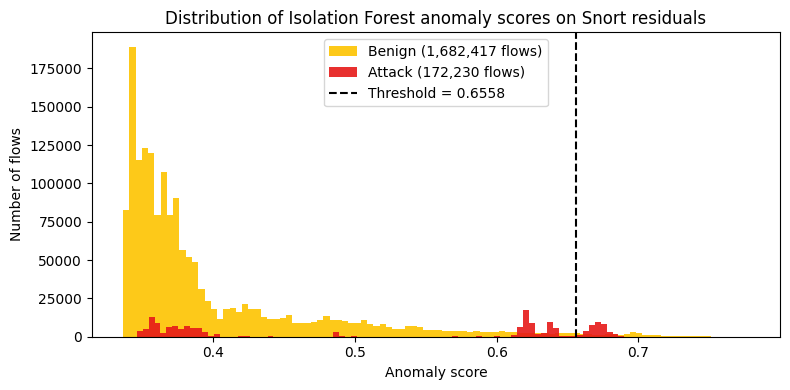

In [5]:
# Apply model to all residuals
X_res = residuals[FEATURES].astype(float)

res_scores = -iso.score_samples(X_res)
res_pred   = (res_scores >= THRESHOLD).astype(int)  # 1 = anomaly, 0 = normal
y_true     = (residuals['Label'] != 'BENIGN').astype(int)  # ground truth for evaluation

print(f'Evaluated flows: {len(residuals):,}')

# Score distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(res_scores[y_true == 0], bins=100, alpha=0.9, color='#FDC400',
        label=f'Benign ({int((y_true == 0).sum()):,} flows)')
ax.hist(res_scores[y_true == 1], bins=100, alpha=0.9, color='#E61918',
        label=f'Attack ({int((y_true == 1).sum()):,} flows)')
ax.axvline(THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'Threshold = {THRESHOLD:.4f}')
ax.set_xlabel('Anomaly score')
ax.set_ylabel('Number of flows')
ax.set_title('Distribution of Isolation Forest anomaly scores on Snort residuals')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'isolation_forest_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Cell 6 – Evaluation

- confusion matrix: shows the distribution of TP, FP, FN and TN
- standard metrics: precision, recall, F1 score, FPR and PR-AUC of the Isolation Forest on the residuals
- precision-recall curve: shows the trade-off between precision and recall across all possible thresholds
- pipeline metrics: CDR, ΔRecall and ΔFPR assess the incremental contribution of the second stage to the overall system
- detection rate per attack class: number of attack types detected by the Isolation Forest

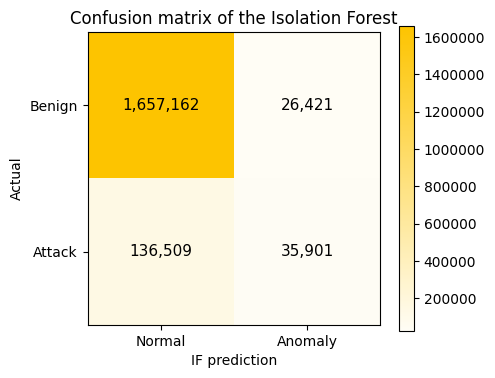

Standard metrics (IF on residuals):


,TP,FP,FN,TN,Precision (%),Recall (%),F1-Score (%),FPR (%),PR-AUC
0,35901,26421,136509,1657162,57.61,20.82,30.59,1.57,0.36


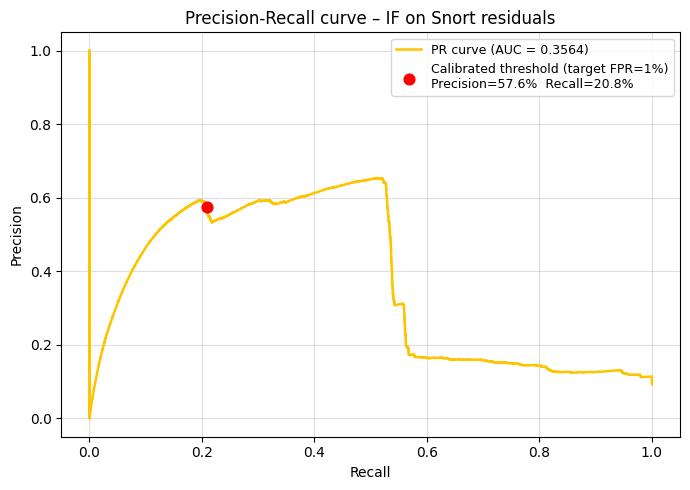


Pipeline metrics:


,Value (%)
Metric,
Recall Snort (Stage 1),69.08
CDR – recall IF on Snort FN,20.82
ΔRecall (gain from IF),6.44
Recall Hybrid (total),75.52
FPR Snort (Stage 1),3.39
ΔFPR (increase from IF),1.52
FPR Hybrid (total),4.90



Detection rate per attack class (IF):


,Count,Detected,Rate (%)
Label,,,
DoS Hulk,60049,29605,49.30
DDoS,92064,6246,6.78
Bot,1739,39,2.24
Infiltration,31,10,32.26
Heartbleed,1,1,100.00
DoS GoldenEye,2209,0,0.00
DoS Slowhttptest,3906,0,0.00
DoS slowloris,3526,0,0.00
FTP-Patator,1513,0,0.00


In [6]:
# Confusion matrix
cm_clean = confusion_matrix(y_true, res_pred, labels=[0, 1])
_, fp, _, tp = cm_clean.ravel()

# Total FN/TN: Snort values minus the flows detected resp. falsely flagged by the IF
fn = FN_SNORT - tp
tn = TN_SNORT - fp

cm = np.array([[tn, fp], [fn, tp]])

fig, ax = plt.subplots(figsize=(5, 4))
cmap_yellow = LinearSegmentedColormap.from_list('yellow', ['#FFFDF5', '#FDC400'])
im = ax.imshow(cm, cmap=cmap_yellow)

ax.set_xticks([0, 1]); ax.set_xticklabels(['Normal', 'Anomaly'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Benign', 'Attack'])
ax.set_xlabel('IF prediction')
ax.set_ylabel('Actual')
ax.set_title('Confusion matrix of the Isolation Forest')

for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                color='black', fontsize=11)

cb = plt.colorbar(im, ax=ax)
cb.formatter.set_useOffset(False)
cb.formatter.set_scientific(False)
cb.update_ticks()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix_isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()

# Standard metrics
pre    = tp / (tp + fp) if (tp + fp) > 0 else 0
rec    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1     = 2 * pre * rec / (pre + rec) if (pre + rec) > 0 else 0
fpr_if = fp / (fp + tn) if (fp + tn) > 0 else 0
pr_auc = average_precision_score(y_true, res_scores)

print('Standard metrics (IF on residuals):')
display(pd.DataFrame([{
    'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
    'Precision (%)': round(pre    * 100, 2),
    'Recall (%)':    round(rec    * 100, 2),
    'F1-Score (%)':  round(f1     * 100, 2),
    'FPR (%)':       round(fpr_if * 100, 2),
    'PR-AUC':        round(pr_auc,        4),
}]))

# PR curve
prec_curve, rec_curve, _ = precision_recall_curve(y_true, res_scores)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec_curve, prec_curve, lw=1.8, color='#FDC400',
        label=f'PR curve (AUC = {pr_auc:.4f})')
ax.scatter([rec], [pre], color='red', zorder=5, s=60,
           label=f'Calibrated threshold (target FPR=1%)\n'
                 f'Precision={pre*100:.1f}%  Recall={rec*100:.1f}%')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curve – IF on Snort residuals')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pr_kurve.png', dpi=150, bbox_inches='tight')
plt.show()

# Pipeline metrics measure the incremental contribution of the IF to the overall pipeline
CDR          = tp / FN_SNORT
DELTA_RECALL = tp / TOTAL_ATTACKS
DELTA_FPR    = fp / TOTAL_NORMAL
RECALL_HYB   = (TP_SNORT + tp) / TOTAL_ATTACKS
FPR_HYB      = (FP_SNORT + fp) / TOTAL_NORMAL

print('\nPipeline metrics:')
display(pd.DataFrame([
    {'Metric': 'Recall Snort (Stage 1)',       'Value (%)': round(TP_SNORT/TOTAL_ATTACKS * 100, 2)},
    {'Metric': 'CDR – recall IF on Snort FN',  'Value (%)': round(CDR          * 100, 2)},
    {'Metric': 'ΔRecall (gain from IF)',       'Value (%)': round(DELTA_RECALL  * 100, 2)},
    {'Metric': 'Recall Hybrid (total)',        'Value (%)': round(RECALL_HYB   * 100, 2)},
    {'Metric': 'FPR Snort (Stage 1)',          'Value (%)': round(FP_SNORT/TOTAL_NORMAL * 100, 2)},
    {'Metric': 'ΔFPR (increase from IF)',      'Value (%)': round(DELTA_FPR    * 100, 2)},
    {'Metric': 'FPR Hybrid (total)',           'Value (%)': round(FPR_HYB      * 100, 2)},
]).set_index('Metric'))

# Detection rate per attack class
classes = (
    residuals[['Label']].assign(Anomaly=res_pred)
    .groupby('Label')
    .agg(Count=('Anomaly','size'), Detected=('Anomaly','sum'))
)
classes['Rate (%)'] = (classes['Detected'] / classes['Count'] * 100).round(2)
classes = classes[classes.index != 'BENIGN'].sort_values('Detected', ascending=False)
print('\nDetection rate per attack class (IF):')
display(classes)

## Cell 7 – ΔRecall-ΔFPR Curve

- the curve shows the trade-off between recall and FPR for different thresholds
- each point corresponds to a threshold, and the red point marks the threshold at 1 percent target FPR.
- the table summarizes the trade-off numerically for six selected target FPR values.

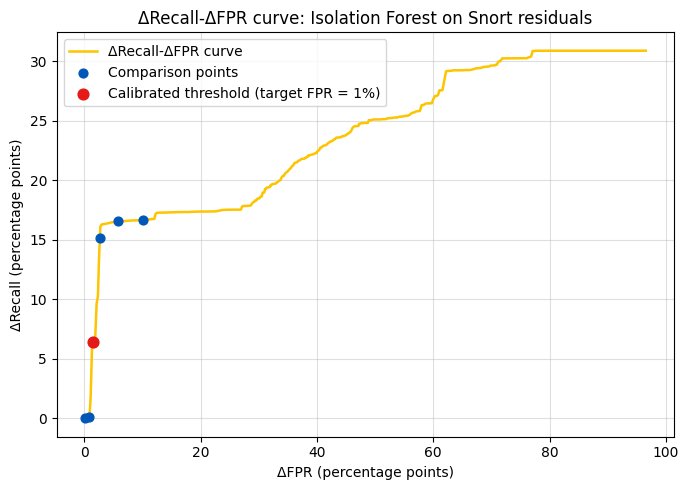

Impact of different thresholds:


,Target FPR (%),Threshold,TP (IF),FP (IF),CDR (%),ΔRecall (%),ΔFPR (%),Recall Hybrid (%),FPR Hybrid (%)
0,0.10,0.73,9,2013,0.01,0.00,0.12,69.08,3.50
1,0.50,0.69,773,15561,0.45,0.14,0.89,69.22,4.28
2,1.00,0.66,35901,26421,20.82,6.44,1.52,75.52,4.90
3,2.00,0.62,84454,46023,48.98,15.14,2.64,84.23,6.03
4,5.00,0.55,92245,100404,53.50,16.54,5.76,85.62,9.15
5,10.00,0.50,92868,176647,53.86,16.65,10.14,85.74,13.53


In [7]:
# Compute 500 points for the curve
thresholds = np.unique(np.percentile(val_scores, np.linspace(0, 99.9, 500)))
d_recalls, d_fprs = [], []

for t in thresholds:
    _tp = int(((res_scores >= t) & (y_true == 1)).sum())
    _fp = int(((res_scores >= t) & (y_true == 0)).sum())
    d_recalls.append(_tp / TOTAL_ATTACKS * 100)
    d_fprs.append(_fp / TOTAL_NORMAL * 100)

# Compute 6 exact table points
TARGET_FPRS = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]
rows = []
tab_recalls, tab_fprs = [], []

for target_fpr in TARGET_FPRS:
    t = float(np.quantile(val_scores, 1.0 - target_fpr))
    _tp = int(((res_scores >= t) & (y_true == 1)).sum())
    _fp = int(((res_scores >= t) & (y_true == 0)).sum())
    tab_recalls.append(_tp / TOTAL_ATTACKS * 100)
    tab_fprs.append(_fp / TOTAL_NORMAL * 100)
    rows.append({
        'Target FPR (%)':    round(target_fpr * 100, 1),
        'Threshold':         round(t, 4),
        'TP (IF)':           _tp, 'FP (IF)': _fp,
        'CDR (%)':           round(_tp/FN_SNORT * 100, 2),
        'ΔRecall (%)':       round(_tp/TOTAL_ATTACKS * 100, 2),
        'ΔFPR (%)':          round(_fp/TOTAL_NORMAL * 100, 4),
        'Recall Hybrid (%)': round((TP_SNORT+_tp)/TOTAL_ATTACKS * 100, 2),
        'FPR Hybrid (%)':    round((FP_SNORT+_fp)/TOTAL_NORMAL * 100, 2),
    })

# Curve with marked points
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(d_fprs, d_recalls, lw=1.8, color='#FDC400', label='ΔRecall-ΔFPR curve')
ax.scatter(tab_fprs, tab_recalls, color='#0057B8', zorder=5, s=40, label='Comparison points')
ax.scatter([DELTA_FPR * 100], [DELTA_RECALL * 100], color='#E61918', zorder=6, s=60,
           label=f'Calibrated threshold (target FPR = 1%)')
ax.set_xlabel('ΔFPR (percentage points)')
ax.set_ylabel('ΔRecall (percentage points)')
ax.set_title('ΔRecall-ΔFPR curve: Isolation Forest on Snort residuals')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'deltaRecall_deltaFPR.png', dpi=150)
plt.show()

print('Impact of different thresholds:')
display(pd.DataFrame(rows))

## Cell 8 – Robustness Analysis: Multiple Seeds

- Isolation Forest contains randomness in tree construction – results can vary slightly depending on the seed
- ten different seeds are tested - with threshold (target FPR 1%)
- results are computed per seed and reported as mean ± standard deviation

In [8]:
SEEDS = [2, 8, 14, 26, 38, 42, 56, 64, 88, 92]

# Train/val split stays identical across all seeds – only the tree construction varies
X_tr, X_v = train_test_split(X_benign, test_size=0.20, random_state=RANDOM_STATE, shuffle=True)

results = []
for seed in SEEDS:
    model = IsolationForest(n_estimators=300, random_state=seed, n_jobs=-1)
    model.fit(X_tr)

    # Threshold is calibrated per seed on the validation data
    threshold = float(np.quantile(-model.score_samples(X_v), 1.0 - TARGET_FPR))
    scores_i  = -model.score_samples(X_res)
    r_pred    = (scores_i >= threshold).astype(int)

    # ravel() order for labels=[0,1]: TN, FP, FN, TP
    _, fp_i, _, tp_i = confusion_matrix(y_true, r_pred, labels=[0, 1]).ravel()

    # Compute FN/TN relative to the Snort baseline values
    fn_i    = FN_SNORT - tp_i
    tn_i    = TN_SNORT - fp_i
    rec_i   = tp_i / (tp_i + fn_i)  if (tp_i + fn_i) > 0 else 0
    pre_i   = tp_i / (tp_i + fp_i)  if (tp_i + fp_i) > 0 else 0
    f1_i    = 2 * pre_i * rec_i / (pre_i + rec_i) if (pre_i + rec_i) > 0 else 0
    fpr_i   = fp_i / (fp_i + tn_i)  if (fp_i + tn_i) > 0 else 0
    prauc_i = average_precision_score(y_true, scores_i)

    results.append({
        'Seed':              seed,
        'TP':                tp_i,
        'FP':                fp_i,
        'FN':                fn_i,
        'TN':                tn_i,
        'Precision (%)':     round(pre_i   * 100, 2),
        'Recall (%)':        round(rec_i   * 100, 2),
        'F1-Score (%)':      round(f1_i    * 100, 2),
        'FPR (%)':           round(fpr_i   * 100, 4),
        'PR-AUC':            round(prauc_i,        4),
        'CDR (%)':           round(tp_i / FN_SNORT                   * 100, 2),
        'ΔRecall (%)':       round(tp_i / TOTAL_ATTACKS               * 100, 2),
        'ΔFPR (%)':          round(fp_i / TOTAL_NORMAL                * 100, 4),
        'Recall Hybrid (%)': round((TP_SNORT + tp_i) / TOTAL_ATTACKS  * 100, 2),
        'FPR Hybrid (%)':    round((FP_SNORT + fp_i) / TOTAL_NORMAL   * 100, 2),
    })

df_seeds = pd.DataFrame(results).set_index('Seed')

# Separate output: classic IF metrics and pipeline metrics
STANDARD = ['TP', 'FP', 'FN', 'TN', 'Precision (%)', 'Recall (%)', 'F1-Score (%)', 'FPR (%)', 'PR-AUC']
PIPELINE = ['CDR (%)', 'ΔRecall (%)', 'ΔFPR (%)', 'Recall Hybrid (%)', 'FPR Hybrid (%)']

print("Standard metrics per seed:")
display(df_seeds[STANDARD])
print("\nPipeline metrics per seed:")
display(df_seeds[PIPELINE])

print(f"\nMean ± standard deviation over {len(SEEDS)} runs:")
display(pd.DataFrame({
    'Mean': df_seeds.mean().round(4),
    'Std':  df_seeds.std().round(4),
}).T)

Standard metrics per seed:


,TP,FP,FN,TN,Precision (%),Recall (%),F1-Score (%),FPR (%),PR-AUC
Seed,,,,,,,,,
2,33105,26578,139305,1657005,55.47,19.20,28.53,1.58,0.35
8,34624,25072,137786,1658511,58.00,20.08,29.83,1.49,0.35
14,34587,25512,137823,1658071,57.55,20.06,29.75,1.52,0.36
26,36111,25317,136299,1658266,58.79,20.94,30.89,1.50,0.37
38,36338,25477,136072,1658106,58.79,21.08,31.03,1.51,0.37
42,35901,26421,136509,1657162,57.61,20.82,30.59,1.57,0.36
56,36000,28338,136410,1655245,55.95,20.88,30.41,1.68,0.35
64,36067,25575,136343,1658008,58.51,20.92,30.82,1.52,0.36
88,36251,25489,136159,1658094,58.72,21.03,30.96,1.51,0.38



Pipeline metrics per seed:


,CDR (%),ΔRecall (%),ΔFPR (%),Recall Hybrid (%),FPR Hybrid (%)
Seed,,,,,
2,19.20,5.94,1.53,75.02,4.91
8,20.08,6.21,1.44,75.29,4.83
14,20.06,6.20,1.46,75.28,4.85
26,20.94,6.48,1.45,75.56,4.84
38,21.08,6.52,1.46,75.60,4.85
42,20.82,6.44,1.52,75.52,4.90
56,20.88,6.46,1.63,75.54,5.01
64,20.92,6.47,1.47,75.55,4.86
88,21.03,6.50,1.46,75.58,4.85



Mean ± standard deviation over 10 runs:


,TP,FP,FN,TN,Precision (%),Recall (%),F1-Score (%),FPR (%),PR-AUC,CDR (%),ΔRecall (%),ΔFPR (%),Recall Hybrid (%),FPR Hybrid (%)
Mean,35529.60,26056.60,136880.40,1657526.40,57.69,20.61,30.36,1.55,0.36,20.61,6.37,1.50,75.45,4.88
Std,1072.87,991.41,1072.87,991.41,1.17,0.62,0.79,0.06,0.01,0.62,0.19,0.06,0.19,0.06
